# Binomial & Poisson on different data: survival & quakes

*Part 1 · Lesson 8 · another dataset  ·  data: Titanic · USGS earthquakes*

*↩ A companion to [Lesson 8: Binomial & Poisson — counting events](08-binomial-poisson.ipynb).*

**↩ Back:** [Lesson 8: Binomial & Poisson — counting events](08-binomial-poisson.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it →](08-binomial-poisson~the-code.ipynb)

The core lesson met the two great *counting* models — the **Binomial** (how many successes in a fixed number of tries) and the **Poisson** (how many rare events in a fixed window of time) — on low-birthweight babies and busy worldwide earthquakes. Here we meet **the same two models on different data**, chosen on purpose to look different:

- a Binomial with a much **bigger** success chance — survival aboard the **Titanic** (about 39 in 100, versus the births' 8 in 100), so its histogram sits further from the wall at zero;
- a Poisson that is **rarer** — only the larger **magnitude-5+** earthquakes per day (about 3.6 a day, versus the core's busy 17), so its shape is lopsided and choppy instead of a near-symmetric mound.

Same two formulas, different rates — and watching them bend with the rate is the whole point. Run each grey cell with **Shift+Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()
rng = np.random.default_rng(12)  # fixed seed -> reproducible; learner can change it

# Part A data: every passenger on the Titanic (one row per person).
tit = sl.load_csv('titanic.csv',
                  url='https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv')
print(f'{len(tit)} passengers loaded')
tit[['Survived', 'Sex', 'Age', 'Pclass']].head()

887 passengers loaded


,Survived,Sex,Age,Pclass
0,0,male,22.0,3
1,1,female,38.0,1
2,1,female,26.0,3
3,1,female,35.0,1
4,0,male,35.0,3


## 1) The building block: a Bernoulli trial

Every count in this lesson is built from the simplest random thing there is: a single **yes/no** event. A trial with exactly two outcomes — "success" (1) or "failure" (0) — is a **Bernoulli trial**, named after Jacob Bernoulli.

- **The math.** One number does the whole job: $p$, the probability of success. Then $P(\text{success}) = p$ and $P(\text{failure}) = 1 - p$.
- **The meaning.** $p$ is the long-run *fraction* of trials that come up "success."
- **The interpretation.** For us, one passenger either **survived** the sinking (1) or did not (0). The `Survived` column is already a column of 0s and 1s — a stack of Bernoulli trials we can read straight off the data. ("Success" is just statistics jargon for "the thing we're counting"; here it happens to be a genuinely hopeful one.)

Let's read $p$, the survival rate, straight off the data.

In [2]:
# Success = a passenger survived. Estimate p as the observed fraction of 1s.
n_surv = int(tit['Survived'].sum())
p = tit['Survived'].mean()
print(f"survivors: {n_surv} out of {len(tit)}")
print(f"p = P(survived) = {p:.3f}")

# A quick reality check: the famous "women and children first" split.
by_sex = tit.groupby('Sex')['Survived'].mean()
print(f"\nfor context, survival rate was {by_sex['female']:.3f} for women and "
      f"{by_sex['male']:.3f} for men")

survivors: 342 out of 887
p = P(survived) = 0.386

for context, survival rate was 0.742 for women and 0.190 for men


**Contrast with the core lesson.** There, "success" (a low-birthweight baby) had $p \approx 0.08$ — a fairly *rare* outcome. Here $p \approx 0.39$ is much closer to a coin flip. That single difference will visibly reshape everything below: a bigger $p$ pushes the whole distribution to the right, away from the wall at zero. (The women-vs-men split is a strong reminder that this one overall $p$ averages over very different groups — a thread the probability lessons pull on.)

## 2) The Binomial distribution — successes in $n$ tries

Now stack $n$ **independent** Bernoulli trials (*independent* = one trial's result tells you nothing about the next), each with the same $p$, and count the successes. That count is a **Binomial** random variable, written $X \sim \text{Binomial}(n, p)$ — read the squiggle "$\sim$" as **"follows the … distribution"** (so: "$X$ follows a Binomial distribution with settings $n$ and $p$").

Picture a random group of **$n = 20$ passengers**, each drawn from the full ship's-worth of people. How many will turn out to be survivors? It could be 0, or 1, ... up to 20 — but not all answers are equally likely.

- **The math.** The probability of *exactly* $k$ successes is
$$P(X = k) = \binom{n}{k}\, p^{k}\,(1-p)^{\,n-k}.$$
The piece $p^k(1-p)^{n-k}$ is the chance of one specific pattern with $k$ successes; $\binom{n}{k} = \frac{n!}{k!\,(n-k)!}$ counts how many different patterns give $k$ successes.
- **The meaning.** It spreads a total probability of 1 across the possible counts $0,1,\dots,n$ — this list is the **PMF** (probability mass function).
- **The interpretation.** It tells us, *before we look*, how surprising any particular number of survivors in a group of 20 would be.

Two summary numbers fall out of the formula:

$$\text{mean} = np, \qquad \text{variance} = np(1-p).$$

In [3]:
n = 20
mean_binom = n * p
var_binom  = n * p * (1 - p)
print(f"Model: X ~ Binomial(n={n}, p={p:.3f})")
print(f"Theory mean     = n*p       = {mean_binom:.2f} survivors per group of 20")
print(f"Theory variance = n*p*(1-p) = {var_binom:.2f}")
print(f"Theory std dev  = sqrt(var) = {np.sqrt(var_binom):.2f}")

Model: X ~ Binomial(n=20, p=0.386)
Theory mean     = n*p       = 7.71 survivors per group of 20
Theory variance = n*p*(1-p) = 4.74
Theory std dev  = sqrt(var) = 2.18


**Note the center.** The mean $np \approx 7.7$ survivors out of 20 sits well to the right — about 39% of the group, as it must. In the core lesson the rare-event mean was barely 2 out of 30, pinned near the left wall. Bigger $p$, center shifts right: that is the lever we are watching.

## 3) Simulate it — don't just believe the formula

Here is the heart of "by seeing it happen." Instead of trusting the formula, we'll *run the experiment* thousands of times: draw a random group of 20 passengers (**with replacement** — we treat the ship's roster as an endless pool with the same survival chance $p$, so each draw is a clean Bernoulli trial), count the survivors, and repeat. Pile the counts into a histogram and the Binomial's shape appears on its own.

The tinkerable knobs are at the top of the cell.

In [4]:
n = 20                # passengers per random group
n_groups = 20000      # how many random groups to simulate
# Each group: 20 independent yes/no draws, "success" with probability p.
draws  = rng.random((n_groups, n)) < p     # True = survived
counts = draws.sum(axis=1)                  # survivors per group of 20

print(f"Simulated {n_groups:,} groups of {n} passengers.")
print(f"Simulated mean     = {counts.mean():.2f}   (theory n*p       = {n*p:.2f})")
print(f"Simulated variance = {counts.var():.2f}   (theory n*p*(1-p) = {n*p*(1-p):.2f})")

Simulated 20,000 groups of 20 passengers.
Simulated mean     = 7.71   (theory n*p       = 7.71)
Simulated variance = 4.82   (theory n*p*(1-p) = 4.74)


**Read those two lines.** The simulated mean and variance land right on the formulas $np$ and $np(1-p)$ — we never plugged the formulas in; the experiment produced them. Now overlay the exact PMF on the histogram of simulated counts. *(The bars are scaled to **probabilities** — their heights sum to 1 — so they line up directly with the formula's red dots, instead of showing raw counts in the thousands.)*

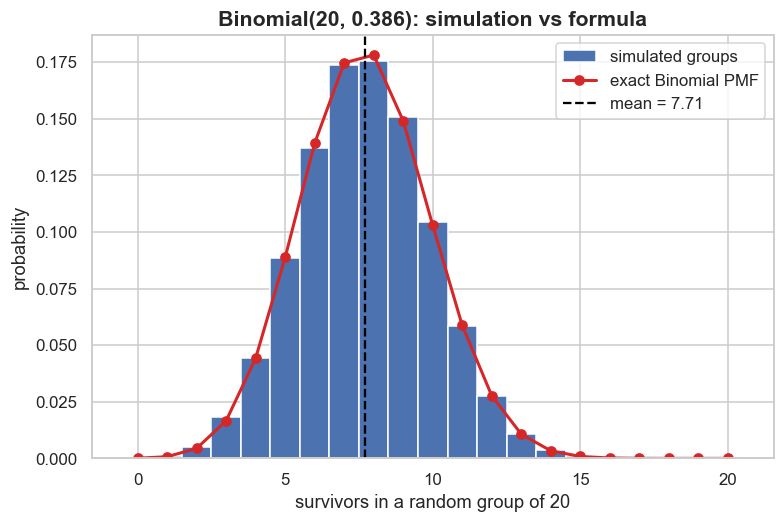

P(exactly 8 survivors in 20) = 0.178
P(5 or fewer)                = 0.155
P(12 or more)                = 0.043


In [5]:
k = np.arange(0, n + 1)                       # possible counts: 0..20
pmf = stats.binom.pmf(k, n, p)                # exact Binomial probabilities

fig, ax = plt.subplots()
ax.hist(counts, bins=np.arange(-0.5, n + 1.5, 1), density=True,
        color='#4c72b0', edgecolor='white', label='simulated groups')
ax.plot(k, pmf, 'o-', color='#d62728', lw=2, label='exact Binomial PMF')
ax.axvline(n * p, color='black', ls='--', lw=1.5, label=f'mean = {n*p:.2f}')
ax.set_xlabel('survivors in a random group of 20')
ax.set_ylabel('probability')
ax.set_title(f'Binomial(20, {p:.3f}): simulation vs formula')
ax.legend(); plt.show()

print(f"P(exactly 8 survivors in 20) = {stats.binom.pmf(8, n, p):.3f}")
print(f"P(5 or fewer)                = {stats.binom.cdf(5, n, p):.3f}")
print(f"P(12 or more)                = {stats.binom.sf(11, n, p):.3f}")

**The interpretation.** The red dots sit right on the blue bars: formula and experiment agree. In a random group of 20 passengers we'd most often see **7 or 8** survivors, wouldn't blink at 5 or 10, and either extreme — *very* few or *most* of the group surviving — is genuinely uncommon. Because $p$ is near a half, this mound is fairly **symmetric** and sits in the middle of the range, not crushed against zero the way the rare low-birthweight count was.

### A sanity check you already trust: a fair coin

To see that the Binomial isn't special to Titanic data, set $p = 0.5$ and flip **20 coins**. The shape becomes a clean symmetric mound centered on 10 heads — and notice how close our survival mound already was to it, because $0.39$ isn't far from $0.5$.

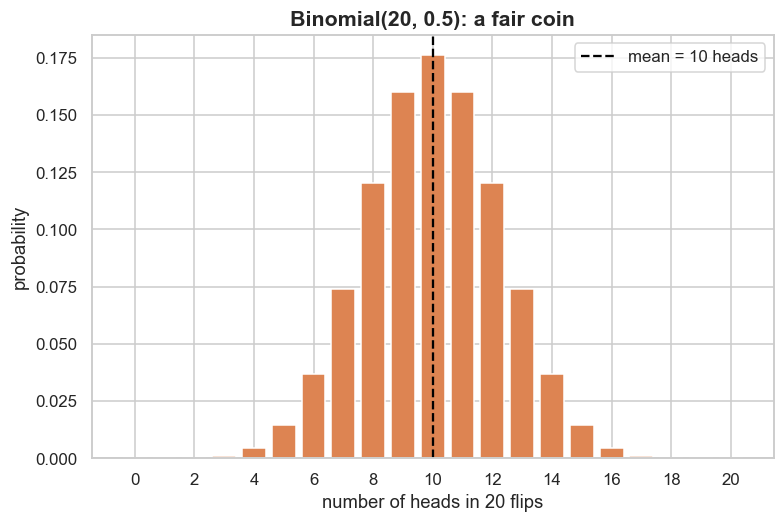

P(exactly 10 heads) = 0.176


In [6]:
n_coins, p_coin = 20, 0.5
k = np.arange(0, n_coins + 1)
pmf_coin = stats.binom.pmf(k, n_coins, p_coin)

fig, ax = plt.subplots()
ax.bar(k, pmf_coin, color='#dd8452', edgecolor='white')
ax.axvline(n_coins * p_coin, color='black', ls='--', lw=1.5,
           label=f'mean = {n_coins*p_coin:.0f} heads')
ax.set_xlabel('number of heads in 20 flips')
ax.set_ylabel('probability')
ax.set_title('Binomial(20, 0.5): a fair coin')
ax.set_xticks(k[::2]); ax.legend(); plt.show()
print(f"P(exactly 10 heads) = {stats.binom.pmf(10, n_coins, p_coin):.3f}")

## 4) The Poisson distribution — rare events per interval

The Binomial needs a fixed number of trials $n$. But many real questions have **no obvious $n$**: how many earthquakes *today*? How many emails *this hour*? There were countless moments when a quake *could* have struck, each with a tiny probability. For "lots of chances, each rare," we use the **Poisson** distribution, written $X \sim \text{Poisson}(\lambda)$.

- **The math.** With a single rate $\lambda$ (the average number of events per interval),
$$P(X = k) = \frac{e^{-\lambda}\,\lambda^{k}}{k!}, \qquad k = 0, 1, 2, \dots$$
- **The meaning.** $\lambda$ is the *typical count per interval*. The Poisson has one famous fingerprint:
$$\text{mean} = \lambda = \text{variance}.$$
The spread equals the average. If a real count's mean and variance are roughly equal, that's a strong hint a Poisson fits.
- **The interpretation.** It answers "how many in one chunk of time?" when events are independent and arrive at a steady average rate.

The core lesson counted *every* M4.5+ quake — a busy ~17 a day. Here we raise the bar to the **bigger M5.0+ quakes**, which are scarcer, and again tally how many happened each day in June 2024.

In [7]:
# Part B data: M4.5+ earthquakes worldwide, June 2024 (USGS) -- same file as the core.
quakes = sl.load_csv(
    'earthquakes_2024_06.csv',
    url='https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv'
        '&starttime=2024-06-01&endtime=2024-07-01&minmagnitude=4.5&orderby=time-asc')

# Keep only the BIGGER quakes: magnitude 5.0 and up (rarer than the core's 4.5+).
big = quakes[quakes['mag'] >= 5.0].copy()
print(f'{len(big)} earthquakes at M5.0+ in June 2024 (out of {len(quakes)} at M4.5+)')

# Build DAILY COUNTS, one number per calendar day. The USGS times end in 'Z'
# (UTC), so floor('D') gives tz-aware days; drop the tz before reindexing to the
# plain June date range, so days with ZERO M5+ quakes are correctly counted as 0.
day = pd.to_datetime(big['time']).dt.floor('D').dt.tz_localize(None)
full_june = pd.date_range('2024-06-01', '2024-06-30')      # all 30 days
daily = day.value_counts().reindex(full_june, fill_value=0)

print(f"days observed    = {len(daily)}")
print(f"mean per day     = {daily.mean():.2f}")
print(f"variance per day = {daily.var(ddof=1):.2f}")
print(f"quietest / busiest day = {daily.min()} / {daily.max()} quakes")

109 earthquakes at M5.0+ in June 2024 (out of 507 at M4.5+)
days observed    = 30
mean per day     = 3.63
variance per day = 2.72
quietest / busiest day = 0 / 7 quakes


**Look at the Poisson fingerprint.** The mean (~3.6 quakes/day) and the variance (~2.7) are close — not glued together as tightly as the core's near-perfect match, but clearly in the same ballpark, which is the practical signal that a Poisson is reasonable. Nothing *forces* a dataset's mean and variance to match, so when they land near each other it's a real hint a Poisson process is at work. And notice the reindex step did its job: some June days saw **zero** M5+ quakes, and those 0s are now counted, not silently dropped. Now overlay the Poisson PMF (using $\lambda$ = the observed mean) on the histogram of daily counts.

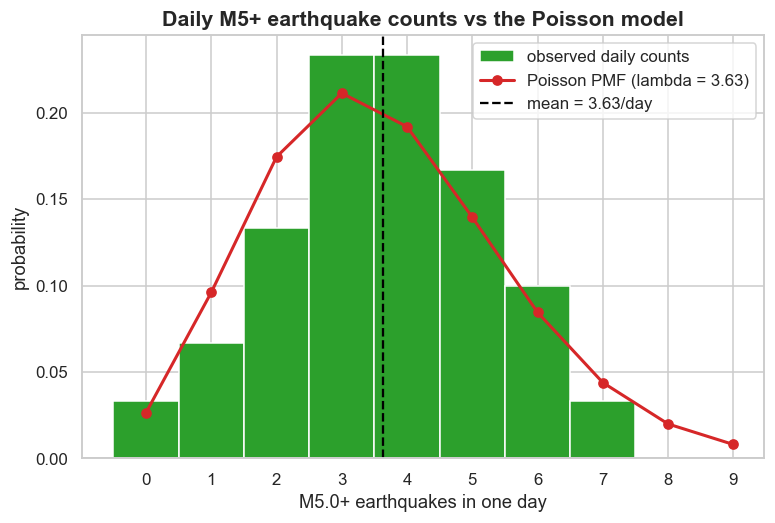

P(0 big quakes on a day) = 0.026
P(<= 2 on a day)         = 0.297
P(>= 7 on a day)         = 0.076


In [8]:
lam = daily.mean()                            # estimate lambda from the data
k = np.arange(0, daily.max() + 3)
pmf = stats.poisson.pmf(k, mu=lam)            # exact Poisson probabilities

fig, ax = plt.subplots()
ax.hist(daily, bins=np.arange(-0.5, daily.max() + 1.5, 1),
        density=True, color='#2ca02c', edgecolor='white',
        label='observed daily counts')
ax.plot(k, pmf, 'o-', color='#d62728', lw=2,
        label=f'Poisson PMF (lambda = {lam:.2f})')
ax.axvline(lam, color='black', ls='--', lw=1.5, label=f'mean = {lam:.2f}/day')
ax.set_xlabel('M5.0+ earthquakes in one day')
ax.set_ylabel('probability')
ax.set_title('Daily M5+ earthquake counts vs the Poisson model')
ax.set_xticks(k); ax.legend(); plt.show()

print(f"P(0 big quakes on a day) = {stats.poisson.pmf(0, lam):.3f}")
print(f"P(<= 2 on a day)         = {stats.poisson.cdf(2, lam):.3f}")
print(f"P(>= 7 on a day)         = {stats.poisson.sf(6, lam):.3f}")

**The interpretation — and the contrast.** With only 30 days the histogram is bumpy, but the red Poisson curve threads through it. The big story is the **shape**: at this low rate $\lambda \approx 3.6$, the distribution is visibly **lopsided** — it leans left, with a real chance of a totally quiet 0-quake day and a long thin tail toward busy days. Compare the core's $\lambda \approx 17$: that one was a fat, nearly *symmetric* mound far from zero. Same Poisson formula, but a *rare* rate makes it discrete and skewed, while a *high* rate makes it smooth and bell-like. (This is "this month's M5+ data"; a different month or cutoff would have its own $\lambda$.)

## 5) The bridge: Binomial becomes Poisson

These two models look unrelated, but they're secretly the same idea. Imagine slicing a day into a *huge* number $n$ of tiny instants, each a Bernoulli trial with a *tiny* chance $p$ of a big quake. That's a Binomial — but with $n$ enormous and $p$ minuscule. As $n \to \infty$ and $p \to 0$ while the product $\lambda = np$ stays fixed and moderate, the Binomial PMF **turns into** the Poisson PMF.

- **The math.** $\text{Binomial}(n, p) \to \text{Poisson}(\lambda)$ as $n\to\infty$, $p\to 0$, with $np = \lambda$.
- **The meaning.** Poisson is the "many trials, each rare" limit of the Binomial — exactly why it models rare events with no obvious $n$.

Let's overlay $\text{Binomial}(1000, 0.0036)$ on $\text{Poisson}(3.6)$ — matching *this* lesson's rarer quake rate — and watch them nearly coincide. (Note this is the **rare-event** $p$, the opposite end from the big survival $p$ of Part A — the bridge only works when $p$ is tiny.)

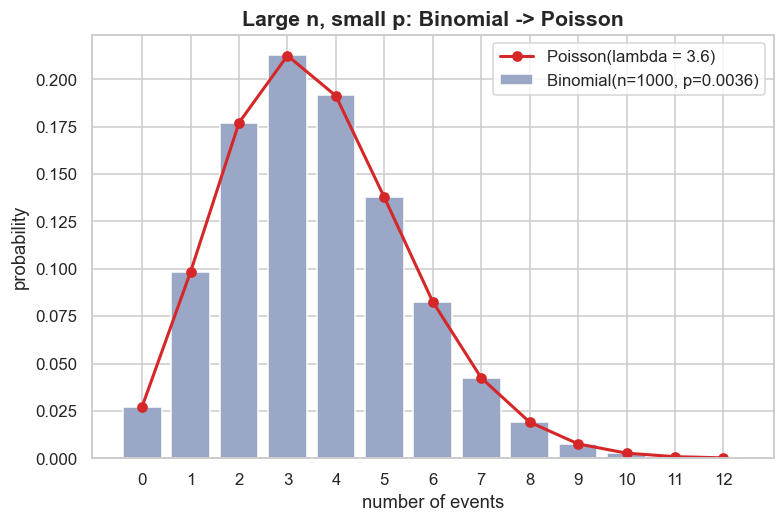

Largest difference between the two PMFs = 0.0004  (essentially identical)


In [9]:
n_big, p_small = 1000, 0.0036
lam_bridge = n_big * p_small                  # = 3.6, matching our M5+ rate
k = np.arange(0, 13)

fig, ax = plt.subplots()
ax.bar(k, stats.binom.pmf(k, n_big, p_small), color='#9aa7c7',
       edgecolor='white', label=f'Binomial(n={n_big}, p={p_small})')
ax.plot(k, stats.poisson.pmf(k, mu=lam_bridge), 'o-', color='#d62728', lw=2,
        label=f'Poisson(lambda = {lam_bridge:.1f})')
ax.set_xlabel('number of events')
ax.set_ylabel('probability')
ax.set_xticks(k)
ax.set_title('Large n, small p: Binomial -> Poisson')
ax.legend(); plt.show()

# How close are they? Largest gap across all counts.
gap = np.abs(stats.binom.pmf(k, n_big, p_small) - stats.poisson.pmf(k, mu=lam_bridge)).max()
print(f"Largest difference between the two PMFs = {gap:.4f}  (essentially identical)")

**One sentence of meaning.** When $n$ is large and $p$ is small with $np$ moderate, "successes out of $n$" and "rare events per interval" are the *same distribution* — so the Poisson is just the Binomial's natural shortcut for rare things, like a big quake on any given day.

## Now you try

Predict first, then change one knob and re-run:

1. **Crank up the success rate.** In the section-3 simulation, the survival $p \approx 0.39$ already pushes the mound near the middle. Imagine a group where survival were $p = 0.74$ (the women-only rate from section 1): force it by replacing `p` with `0.74` in that cell. Which way does the whole histogram slide, and does it bunch up against the *right* wall (20) the way the births bunched against the left?

2. **Lower the magnitude bar back to the core's.** In section 4, change `>= 5.0` to `>= 4.5` and re-run sections 4. The rate $\lambda$ jumps to ~17, and the daily histogram should turn from lopsided into a near-symmetric mound — the core lesson's picture, recovered from the same file.

3. **Break the Poisson bridge.** In section 5, change `n_big, p_small` to `100, 0.036` (still $np = 3.6$, but now $p$ is ten times bigger). Does the Binomial still hug the Poisson, or does the gap grow? What does that tell you about *how small* $p$ has to be for the shortcut to work?

## What you learned

- **Bernoulli trial:** one yes/no event with success probability $p$ — here, whether a passenger survived. The `Survived` column is a stack of them.
- **Binomial** $X\sim\text{Binomial}(n,p)$ counts successes in $n$ independent trials; $P(X=k)=\binom{n}{k}p^k(1-p)^{n-k}$, with **mean $=np$** and **variance $=np(1-p)$** — confirmed by simulating random groups of 20 passengers. A **bigger $p$ ($\approx 0.39$ vs. the births' $\approx 0.08$) shifts the whole distribution right** and makes it more symmetric.
- **Poisson** $X\sim\text{Poisson}(\lambda)$ counts rare events per interval; $P(X=k)=e^{-\lambda}\lambda^k/k!$, with the fingerprint **mean $\approx$ variance $=\lambda$** — seen in daily M5+ quake counts ($\lambda \approx 3.6$). A **rarer rate makes the shape lopsided and choppy**, versus the core's near-symmetric $\lambda \approx 17$.
- Counting zero-event intervals matters: **reindexing** over the full date range kept the quiet, zero-quake days in the tally.
- A model is **believable when the simulation matches the formula** and the data's mean/variance match the model's — not just because a textbook says so.
- **Binomial $\to$ Poisson** as $n\to\infty$, $p\to 0$ with $np=\lambda$: the two counting models are one idea, and the bridge needs the *small*-$p$ end, not the big survival $p$.

---

**↩ Back to the lesson:** [Lesson 8: Binomial & Poisson — counting events](08-binomial-poisson.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it](08-binomial-poisson~the-code.ipynb)